# Logistic Regression

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.feature_selection import chi2, SelectKBest
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv", delimiter=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

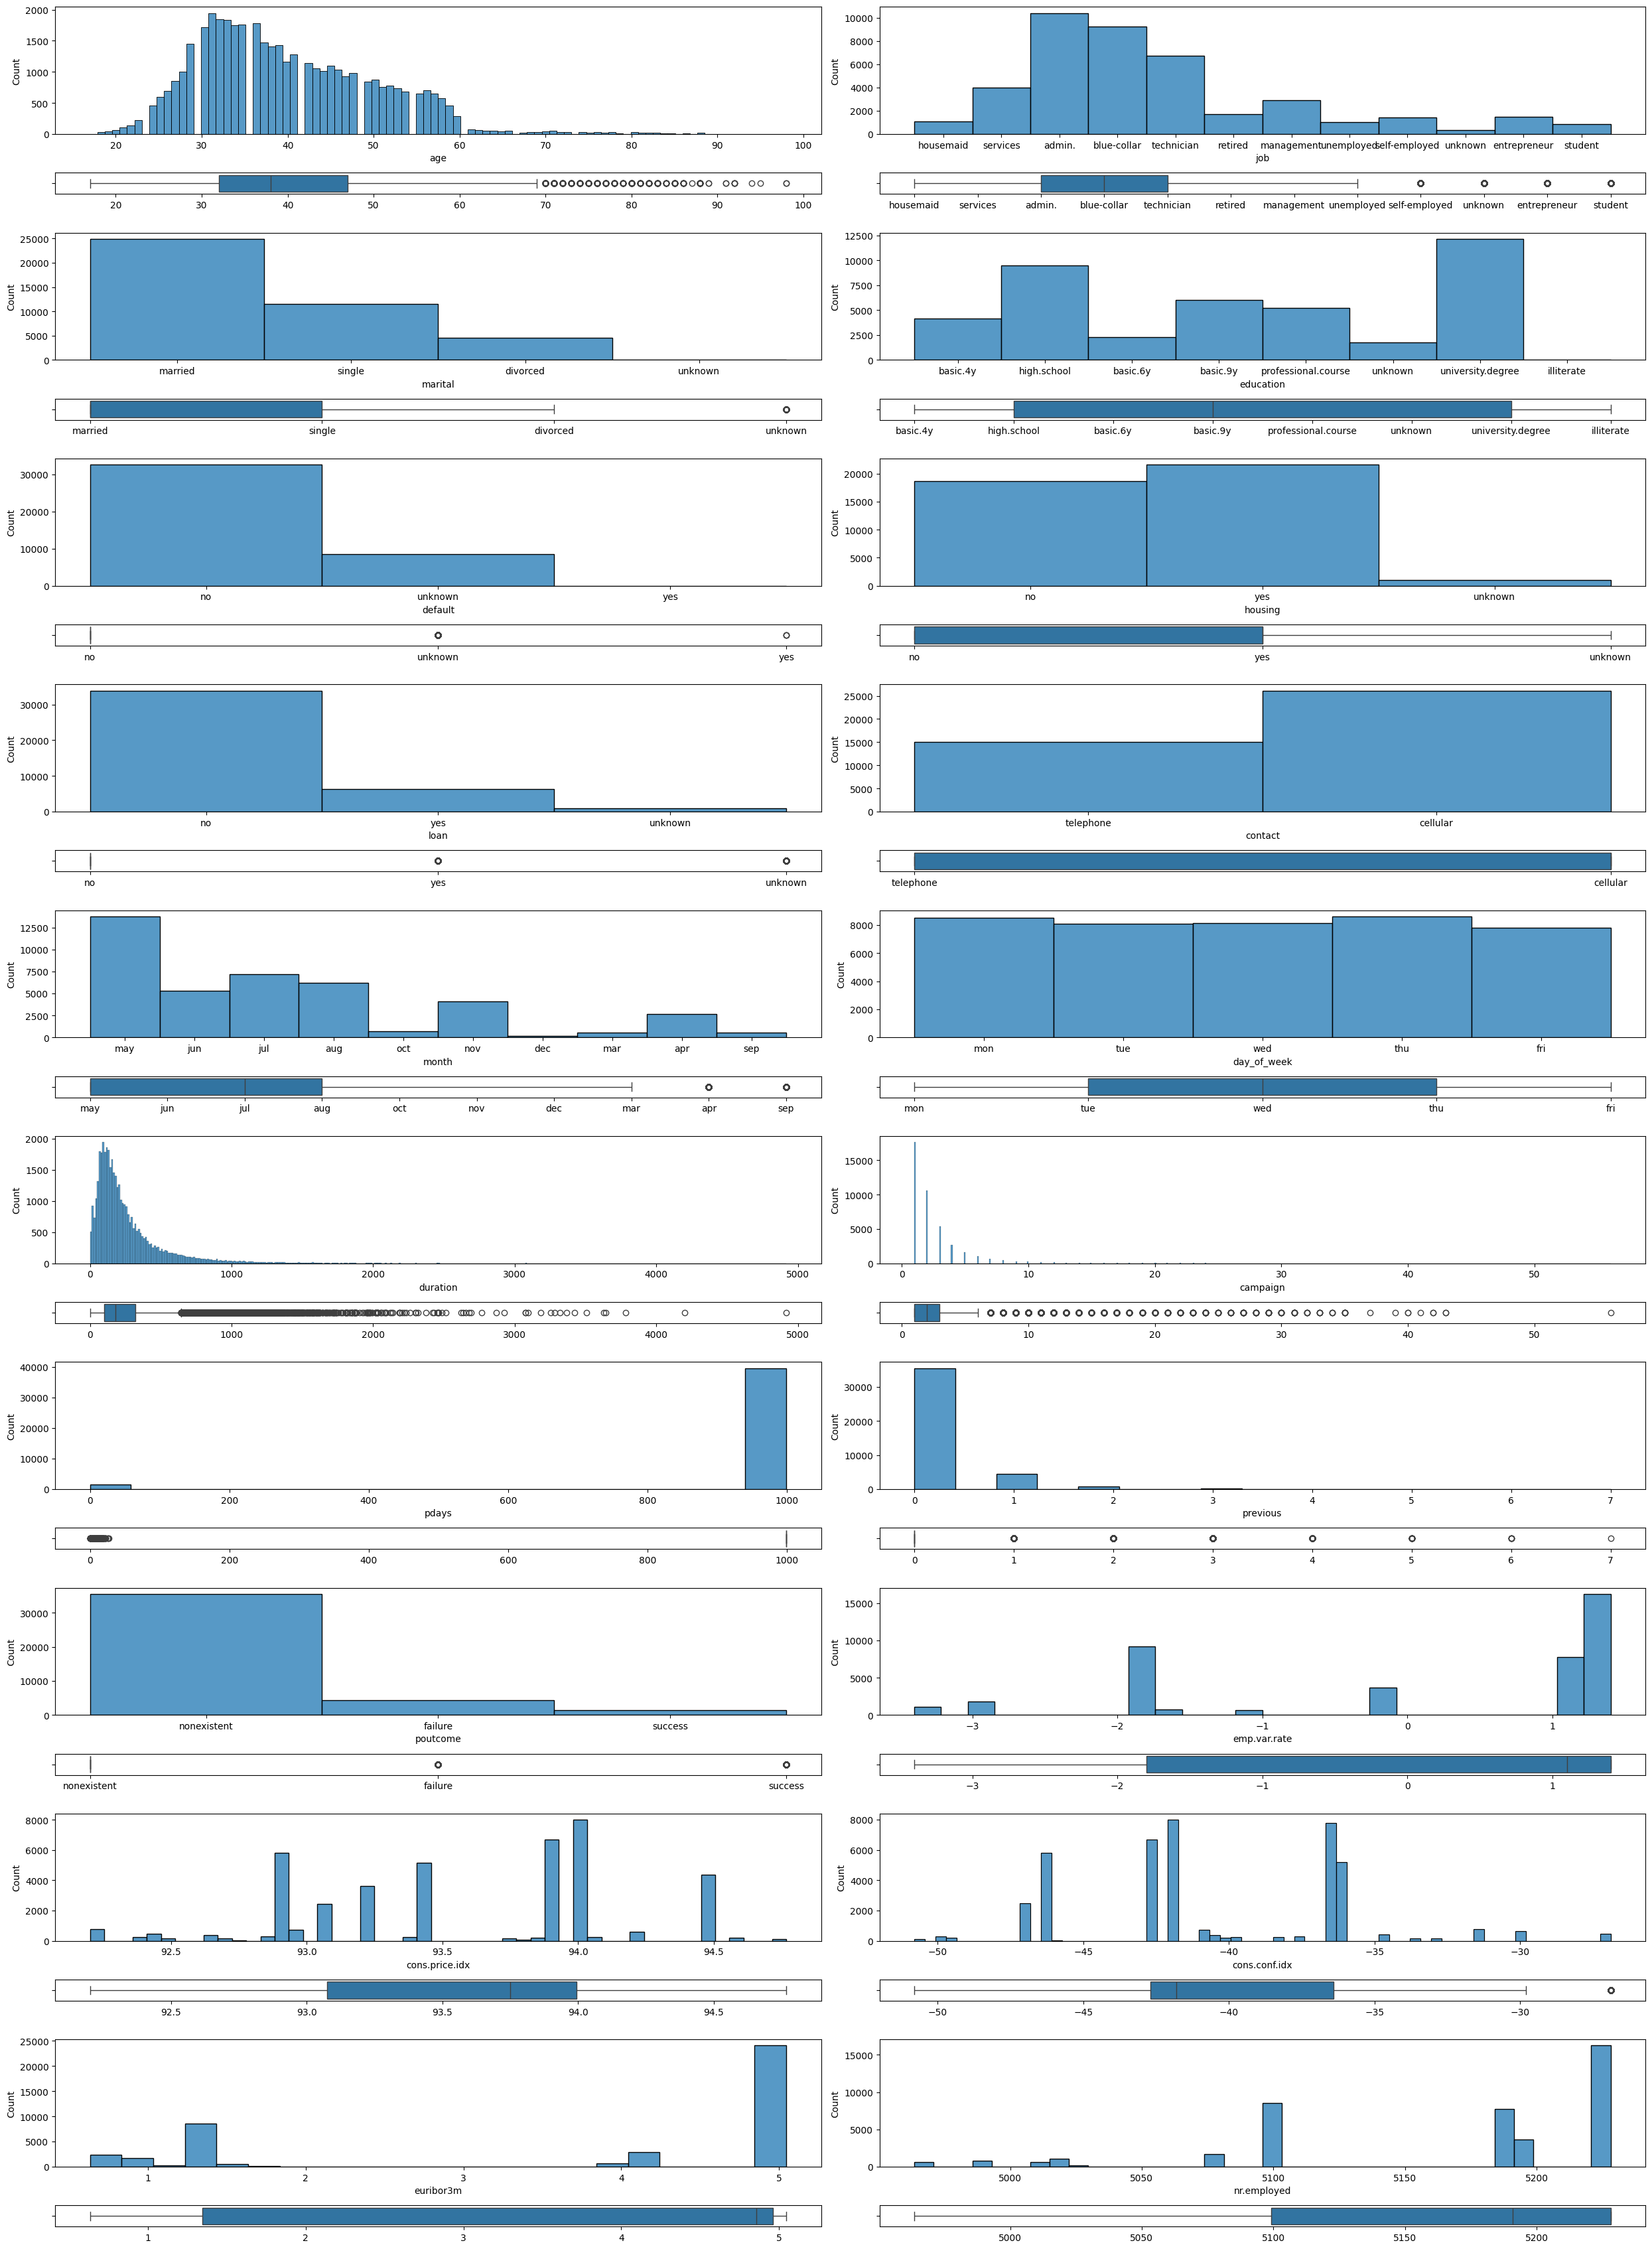

In [45]:
features = df.drop(columns=["y"]).columns

fig, ax = plt.subplots(len(features), 2, figsize=(25, 34), 
                       gridspec_kw={'height_ratios': [6, 1] * (len(features) // 2)})

for i, feature in enumerate(features):
    row = (i // 2) * 2 
    col = i % 2
    sns.histplot(ax=ax[row, col], data=df, x=feature)
    sns.boxplot(ax=ax[row + 1, col], data=df, x=feature).set(xlabel=None)


plt.tight_layout()
plt.show()

1. Age Distribution

    Histogram: The first plot shows the distribution of ages in the dataset. The majority of individuals are between 20 and 60 years old, with a peak around 30-40 years.

2. Job Distribution

    Bar Plot: The second plot shows the distribution of different job categories. The most common job categories are "blue-collar," "management," and "technician."

3. Marital Status

    Bar Plot: The third plot shows the distribution of marital statuses. The majority of individuals are married, followed by single and divorced.

4. Education Level

    Bar Plot: The fourth plot shows the distribution of education levels. The most common education levels are "basic.9y," "high.school," and "university.degree."

5. Default Status

    Bar Plot: The fifth plot shows the distribution of default statuses. Most individuals do not have a default, with a small number having a default or unknown status.

6. Housing Loan

    Bar Plot: The sixth plot shows the distribution of housing loan statuses. Most individuals do not have a housing loan, with a smaller number having a loan or unknown status.

7. Loan Status

    Bar Plot: The seventh plot shows the distribution of loan statuses. Most individuals do not have a loan, with a smaller number having a loan or unknown status.

8. Contact Communication Type

    Bar Plot: The eighth plot shows the distribution of contact communication types. The most common type is "cellular," followed by "telephone."

9. Month of Contact

    Bar Plot: The ninth plot shows the distribution of the month when contact was made. The most common months are May, July, and August.

10. Day of the Week

    Bar Plot: The tenth plot shows the distribution of the day of the week when contact was made. The distribution is fairly even across all days.

11. Duration of Contact

    Histogram: The eleventh plot shows the distribution of the duration of contact in seconds. The distribution is right-skewed, with most contacts lasting less than 1000 seconds.

12. Number of Contacts During Campaign

    Histogram: The twelfth plot shows the distribution of the number of contacts made during the campaign. Most individuals were contacted less than 10 times.

13. Days Since Previous Contact

    Histogram: The thirteenth plot shows the distribution of the number of days since the previous contact. Most individuals were contacted after a long gap or had no previous contact.

14. Outcome of Previous Campaign

    Bar Plot: The fourteenth plot shows the distribution of the outcome of the previous campaign. Most outcomes are "nonexistent," followed by "failure" and "success."

15. Employment Variation Rate

    Histogram: The fifteenth plot shows the distribution of the employment variation rate. The distribution is centered around 0, with some variation.

16. Consumer Price Index

    Histogram: The sixteenth plot shows the distribution of the consumer price index. The distribution is centered around 93.5.

17. Consumer Confidence Index

    Histogram: The seventeenth plot shows the distribution of the consumer confidence index. The distribution is centered around -40.

18. Number of Employees

    Histogram: The eighteenth plot shows the distribution of the number of employees. The distribution is centered around 5000.

General Conclusions:

    Age and Job Categories: The dataset is dominated by individuals aged 20-60, with a concentration in the 30-40 age range. The most common job categories are "blue-collar," "management," and "technician."

    Marital and Education Status: Most individuals are married, with "basic.9y," "high.school," and "university.degree" being the most common education levels.

    Financial Status: Most individuals do not have a default, housing loan, or other loan. This suggests a relatively financially stable demographic.

    Contact Information: The most common contact method is "cellular," and contacts were most frequently made in May, July, and August.

    Campaign Information: Most contacts lasted less than 1000 seconds, and individuals were contacted fewer than 10 times during the campaign. The outcome of the previous campaign was mostly "nonexistent."

In [46]:
df["job_n"] = pd.factorize(df["job"])[0]
df["marital_n"] = pd.factorize(df["marital"])[0]
df["education_n"] = pd.factorize(df["education"])[0]
df["default_n"] = pd.factorize(df["default"])[0]
df["housing_n"] = pd.factorize(df["housing"])[0]
df["loan_n"] = pd.factorize(df["loan"])[0]
df["contact_n"] = pd.factorize(df["contact"])[0]
df["month_n"] = pd.factorize(df["month"])[0]
df["day_of_week_n"] = pd.factorize(df["day_of_week"])[0]
df["poutcome_n"] = pd.factorize(df["poutcome"])[0]
df["y_n"] = df["y"].map({"yes": 1, "no": 0})

if df.isnull().sum().sum() > 0 or df.isna().sum().sum() > 0:
    print("Missing values found")
    df = df.dropna(axis=1)
else:
    print("No missing values")

if df.duplicated().sum() > 0:
    print("Duplicates found")
    df.drop_duplicates(inplace=True)
else:
   print("No duplicates")

df = df.select_dtypes('number')

df.describe()

No missing values
Duplicates found


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n,y_n
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,...,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,...,0.510637,3.277370,0.208908,0.571959,0.199825,0.634714,2.249951,1.979600,0.169953,0.112663
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,...,0.696794,2.185558,0.406713,0.541216,0.456055,0.481516,2.429157,1.411539,0.455811,0.316184
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,...,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,2.000000,2.000000,0.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,...,1.000000,6.000000,0.000000,1.000000,0.000000,1.000000,3.000000,3.000000,0.000000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,...,3.000000,7.000000,2.000000,2.000000,2.000000,1.000000,9.000000,4.000000,2.000000,1.000000


In [47]:
def identify_outliers(df):
    outlier_info = {}

    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1 

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        if not outliers.empty:
            outlier_info[col] = {
                'outliers_count': outliers.shape[0],
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'outlier_values': outliers[col].tolist()
            }

    for col, info in outlier_info.items():
        print(f"Column: {col}")
        print(f"  Number of outliers: {info['outliers_count']}")
        print(f"  Low Limit: {info['lower_bound']}")
        print(f"  High Limit: {info['upper_bound']}")
        print(f"  Outliers: {info['outlier_values'][:5]}...\n")
    return outlier_info

In [48]:
outlier_info = identify_outliers(df)

Column: age
  Number of outliers: 468
  Low Limit: 9.5
  High Limit: 69.5
  Outliers: [70, 76, 73, 88, 88]...

Column: duration
  Number of outliers: 2963
  Low Limit: -223.5
  High Limit: 644.5
  Outliers: [1666, 787, 812, 1575, 1042]...

Column: campaign
  Number of outliers: 2406
  Low Limit: -2.0
  High Limit: 6.0
  Outliers: [7, 8, 8, 7, 7]...

Column: pdays
  Number of outliers: 1515
  Low Limit: 999.0
  High Limit: 999.0
  Outliers: [6, 4, 4, 3, 4]...

Column: previous
  Number of outliers: 5625
  Low Limit: 0.0
  High Limit: 0.0
  Outliers: [1, 1, 1, 1, 1]...

Column: cons.conf.idx
  Number of outliers: 446
  Low Limit: -52.150000000000006
  High Limit: -26.949999999999992
  Outliers: [-26.9, -26.9, -26.9, -26.9, -26.9]...

Column: job_n
  Number of outliers: 4082
  Low Limit: -1.0
  High Limit: 7.0
  Outliers: [8, 9, 9, 10, 10]...

Column: marital_n
  Number of outliers: 80
  Low Limit: -1.5
  High Limit: 2.5
  Outliers: [3, 3, 3, 3, 3]...

Column: default_n
  Number of outlie

In [49]:
def remove_outliers(df, outlier_info):
    
    for col, info in outlier_info.items():
        lower_limit = info['lower_bound']
        upper_limit = info['upper_bound']
        
        if lower_limit < 0:
            df = df[df[col] >= lower_limit]
        if upper_limit > 0:
            df = df[df[col] <= upper_limit]

        
    return df


In [50]:
df_without_outliers = remove_outliers(df, outlier_info=outlier_info)
df_without_outliers.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n,y_n
count,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00,...,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00,29525.00
mean,39.76,204.69,2.07,969.20,0.15,0.26,93.61,-40.20,3.84,5175.70,...,0.50,3.22,0.22,0.57,0.20,0.61,1.73,1.95,0.15,0.07
std,9.50,138.99,1.30,169.41,0.45,1.50,0.57,4.36,1.64,67.07,...,0.69,2.17,0.41,0.54,0.46,0.49,1.78,1.40,0.42,0.25
min,20.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,32.00,100.00,1.00,999.00,0.00,-1.70,93.20,-42.70,1.34,5099.10,...,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
50%,38.00,168.00,2.00,999.00,0.00,1.10,93.92,-41.80,4.86,5195.80,...,0.00,3.00,0.00,1.00,0.00,1.00,1.00,2.00,0.00,0.00
75%,47.00,276.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10,...,1.00,6.00,0.00,1.00,0.00,1.00,3.00,3.00,0.00,0.00
max,69.00,644.00,6.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10,...,2.00,7.00,2.00,2.00,2.00,1.00,7.00,4.00,2.00,1.00


In [51]:
def train_split(target, df, test_size=0.1, random_state=42):
    return train_test_split(df.drop(columns=target), df[target], test_size=test_size, random_state=random_state)

In [52]:
from joblib import dump
from sklearn.discriminant_analysis import StandardScaler


def standard_scaler(X_train, X_test, filename: str):

    scaler = StandardScaler()
    scaler.fit(X_train)
    
    X_train_norm = scaler.transform(X_train)
    X_test_norm = scaler.transform(X_test)

    X_train_norm = pd.DataFrame(X_train_norm, index=X_train.index, columns=X_train.columns)
    X_test_norm = pd.DataFrame(X_test_norm, index=X_test.index, columns=X_test.columns)

    dump(scaler, f'../data/processed/std_transform_{filename}.sav')

    return X_train_norm, X_test_norm

def min_max_scaler(X_train, X_test, reference: str):
    
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    
    X_train_minmax = scaler.transform(X_train)
    X_train_minmax = pd.DataFrame(X_train_minmax, index = X_train.index, columns=X_train.columns)

    X_test_minmax = scaler.transform(X_test)
    X_test_minmax = pd.DataFrame(X_test_minmax, index = X_test.index, columns=X_test.columns)
    
    dump(scaler, f'../data/processed/minmax_{reference}.sav')

    return X_train_minmax, X_test_minmax


In [53]:

TARGET = 'y_n'

X_train_with_outliers, X_test_with_outliers, y_train, y_test = train_split(TARGET, df, test_size=0.2, random_state=42)
X_train_without_outliers, X_test_without_outliers, y_train_without_outliers, y_test_without_outliers  = train_split(TARGET, df_without_outliers, test_size=0.2, random_state=42)

#Default
X_train_with_outliers.to_csv('../data/processed/X_train_with_outliers_ts_02_rs_42.csv', index=False)
X_test_with_outliers.to_csv('../data/processed/X_test_with_outliers_ts_02_rs_42.csv', index=False)

y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

#Without outliers
X_train_without_outliers.to_csv('../data/processed/X_train_without_outliers_ts_02_rs_42.csv', index=False)
X_test_without_outliers.to_csv('../data/processed/X_test_without_outliers_ts_02_rs_42.csv', index=False)

y_train_without_outliers.to_csv('../data/processed/y_train_without_outliers.csv', index=False)
y_test_without_outliers.to_csv('../data/processed/y_test_without_outliers.csv', index=False)





In [54]:
X_train_with_outliers_std, X_test_with_outliers_std = standard_scaler(X_train_with_outliers, X_test_with_outliers, 'with_outliers')
X_train_without_outliers_std, X_test_without_outliers_std = standard_scaler(X_train_without_outliers, X_test_without_outliers, 'without_outliers')

X_train_with_outliers_minmax, X_test_with_outliers_minmax = min_max_scaler(X_train_with_outliers, X_test_with_outliers, 'with_outliers')
X_train_without_outliers_minmax, X_test_without_outliers_minmax = min_max_scaler(X_train_without_outliers, X_test_without_outliers, 'without_outliers')



In [55]:
from sklearn.feature_selection import f_classif


def select_k_best(X_train, X_test, y_train, k, filename: str):

    selection_model = SelectKBest(f_classif, k=k)
    selection_model.fit(X_train, y_train)
    cols = selection_model.get_support()

    dump(selection_model, f'../data/processed/selection_model_{filename}.sav')

    return pd.DataFrame(selection_model.transform(X_train), columns=X_train.columns.values[cols]) , pd.DataFrame(selection_model.transform(X_test), columns=X_test.columns.values[cols])

In [56]:
K = X_train_with_outliers.shape[1]
X_train_with_outliers_selected, X_test_with_outliers_selected = select_k_best(X_train_with_outliers, X_test_with_outliers, y_train, K, 'with_outliers')
X_train_without_outliers_selected, X_test_without_outliers_selected = select_k_best(X_train_without_outliers, X_test_without_outliers, y_train_without_outliers, K, 'without_outliers')

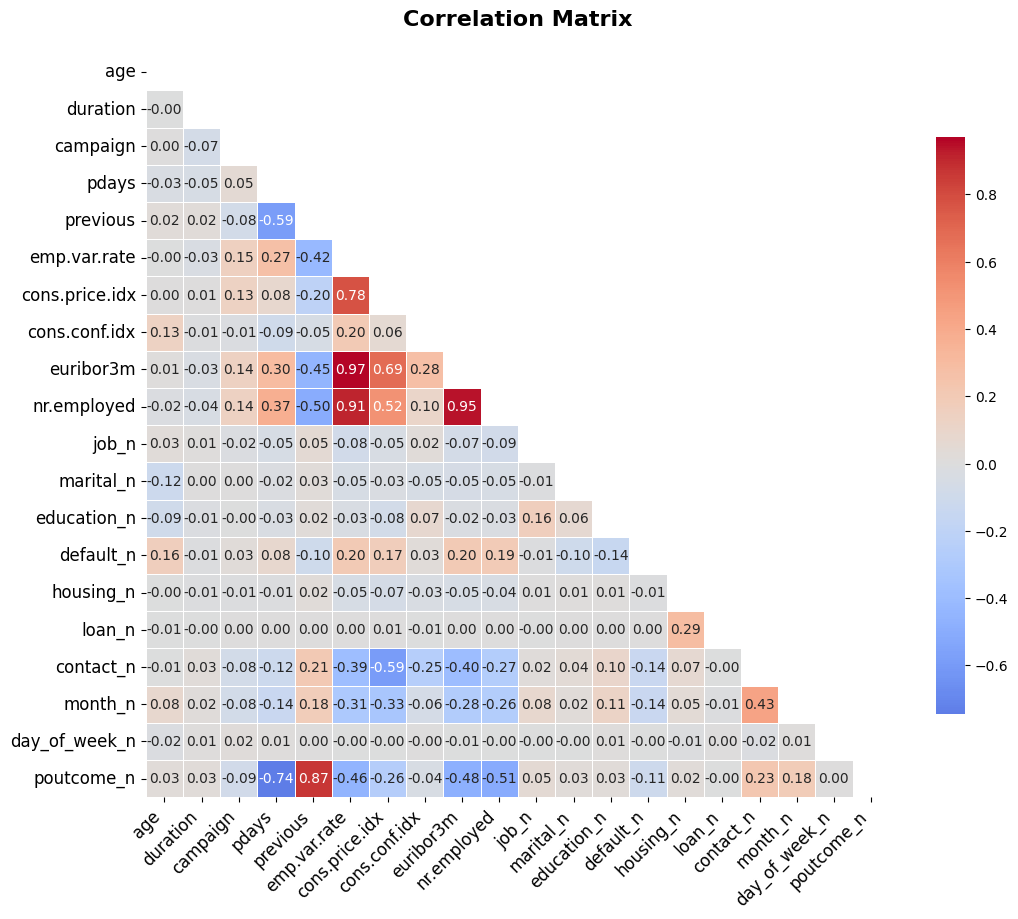

In [57]:
# Correlation heatmap
plt.figure(figsize=(12, 10))

corr_matrix = df[X_train_with_outliers.columns].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16, fontweight="bold", pad=20)
plt.xticks(fontsize=12, rotation=45, ha="right")
plt.yticks(fontsize=12)

plt.show()

A strong positive correlation (0.97) between "euribor3m" and "nr.employed".

A strong negative correlation (-0.74) between "poutcome_n" and "emp.var.rate".

Moderate correlations between "cons.price.idx" and "euribor3m" (0.69), as well as between "cons.price.idx" and "nr.employed" (0.52).

In [58]:
X_train_with_outliers_std_selected = X_train_with_outliers_std[X_train_with_outliers_selected.columns]
X_train_without_outliers_std_selected = X_train_without_outliers_std[X_train_without_outliers_selected.columns]

X_test_with_outliers_std_selected = X_test_with_outliers_std[X_test_with_outliers_selected.columns]
X_test_without_outliers_std_selected = X_test_without_outliers_std[X_test_without_outliers_selected.columns]


X_train_with_outliers_minmax_selected = X_train_with_outliers_minmax[X_train_with_outliers_selected.columns]
X_train_without_outliers_minmax_selected = X_train_without_outliers_minmax[X_train_without_outliers_selected.columns]

X_test_with_outliers_minmax_selected = X_test_with_outliers_minmax[X_test_with_outliers_selected.columns]
X_test_without_outliers_minmax_selected = X_test_without_outliers_minmax[X_test_without_outliers_selected.columns]


In [59]:
dfs_train = {
    'X_train_with_outliers_selected': X_train_with_outliers_selected,
    'X_train_with_outliers_norm_selected': X_train_with_outliers_std_selected,
    'X_train_with_outliers_minmax_selected': X_train_with_outliers_minmax_selected,
}

dfs_train_without_outliers = {
    'X_train_without_outliers_selected': X_train_without_outliers_selected,
    'X_train_without_outliers_norm_selected': X_train_without_outliers_std_selected,
    'X_train_without_outliers_minmax_selected': X_train_without_outliers_minmax_selected 
}

dfs_test = {
    'X_test_with_outliers_selected': X_test_with_outliers_selected,
    'X_test_with_outliers_norm_selected': X_test_with_outliers_std_selected,
    'X_test_with_outliers_minmax_selected': X_test_with_outliers_minmax_selected,
}

dfs_test_without_outliers = {
    'X_test_without_outliers_selected': X_test_without_outliers_selected,
    'X_test_without_outliers_norm_selected': X_test_without_outliers_std_selected,
    'X_test_without_outliers_minmax_selected': X_test_without_outliers_minmax_selected
}



for name, df in dfs_train.items():
    df.to_csv(f"../data/processed/{name}.csv", index=False)

for name, df in dfs_test.items(): 
    df.to_csv(f'../data/processed/{name}.csv', index=False)

for name, df in dfs_train_without_outliers.items():
    df.to_csv(f"../data/processed/{name}.csv", index=False)

for name, df in dfs_test_without_outliers.items(): 
    df.to_csv(f'../data/processed/{name}.csv', index=False)

In [60]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

train = list(dfs_train.values())
test = list(dfs_test.values())
train_without_outliers = list(dfs_train_without_outliers.values())
test_without_outliers = list(dfs_test_without_outliers.values())

results = []

# Default
for index, train_df in enumerate(train):
    model = LogisticRegression(random_state=42)
    model.fit(train_df, y_train)
    y_pred = model.predict(test[index])

    results.append({
        'index': index,
        'df_train': list(dfs_train.keys())[index],
        'Accuracy Score': round(accuracy_score(y_test, y_pred), 4),
        'Classification report': classification_report(y_test, y_pred),
        'Confusion matrix': confusion_matrix(y_test, y_pred)
    })

# Without outliers
for index, train_df in enumerate(train_without_outliers):
    model = LogisticRegression(random_state=42)
    model.fit(train_df, y_train_without_outliers)
    y_pred = model.predict(test_without_outliers[index])

    results.append({
        'index': index,
        'df_train': list(dfs_train_without_outliers.keys())[index],
        'Accuracy Score': round(accuracy_score(y_test_without_outliers, y_pred), 4),
        'Classification report': classification_report(y_test_without_outliers, y_pred),
        'Confusion matrix': confusion_matrix(y_test_without_outliers, y_pred)
    })


results = sorted(results, key=lambda x: x['Accuracy Score'], reverse=True)
best_result = results[0]

print(f"Index: {best_result['index']}")
print(f"\ndf_train: {best_result['df_train']}")
print(f"\nAccuracy Score: {best_result['Accuracy Score']}")
print(f"\nClassification Report: {best_result['Classification report']}")
print(f"\nConfusion Matrix: {best_result['Confusion matrix']}")


Index: 0

df_train: X_train_without_outliers_selected

Accuracy Score: 0.9497

Classification Report:               precision    recall  f1-score   support

           0       0.96      0.99      0.97      5536
           1       0.67      0.38      0.49       369

    accuracy                           0.95      5905
   macro avg       0.81      0.69      0.73      5905
weighted avg       0.94      0.95      0.94      5905


Confusion Matrix: [[5466   70]
 [ 227  142]]


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}


grid = GridSearchCV(LogisticRegression(random_state=42, class_weight="balanced"), hyperparams, scoring='f1', cv=5, verbose=0)

grid

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          random_state=42),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='f1')